# Exploratory Data Analysis

---

Reading and Understanding dataset

In [2]:
# Libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from wordcloud import WordCloud

Matplotlib is building the font cache; this may take a moment.


In [4]:
# loading datasets
customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

In [5]:
#row count of each dataset
print("Customers dataset row count:", customers.shape[0])
print("Orders dataset row count:", orders.shape[0])
print("Payments dataset row count:", payments.shape[0])
print("Reviews dataset row count:", reviews.shape[0])

Customers dataset row count: 99441
Orders dataset row count: 99441
Payments dataset row count: 103886
Reviews dataset row count: 99224


# Srep1 : Basic Exploration

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [9]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [10]:
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [11]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [12]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [14]:
customers.shape


(99441, 5)

In [15]:
orders.shape


(99441, 8)

In [16]:
payments.shape


(103886, 5)

In [17]:
reviews.shape

(99224, 7)

In [18]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [19]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [20]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [21]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


# Step2: Missing values 

In [22]:
#missing values in each dataset
customers.isnull().sum() 

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [23]:
#missing values in each dataset
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [24]:
#missing values in each dataset
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [25]:
#missing values in each dataset
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

# Step 3: Understand Customers

In [29]:
# How many customers are there in the dataset?
customers["customer_unique_id"].nunique()

96096

In [30]:
# How many customer records are there in the dataset?
customers["customer_id"].nunique()

99441

In [31]:
customers.shape

(99441, 5)

# Step 4: Undersytand orders 

In [32]:
# How many order records are there in the dataset?
orders["order_id"].nunique()

99441

In [33]:
# order status distribution
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

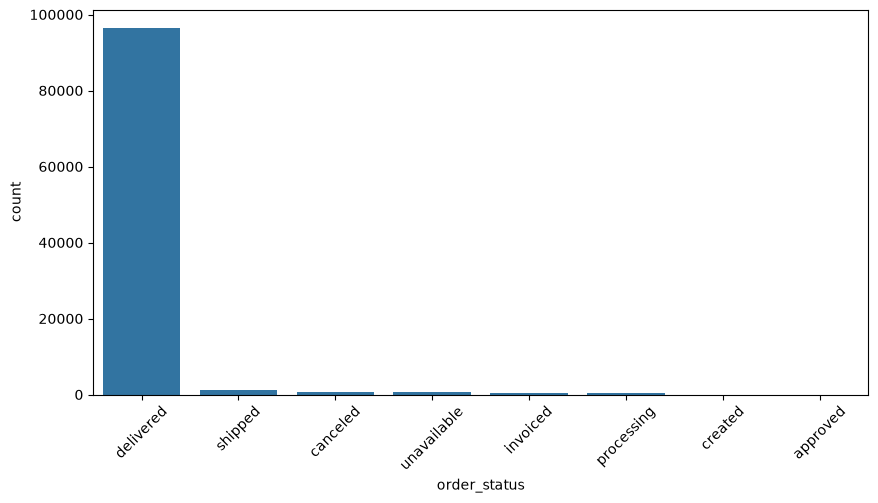

In [34]:
# visualizing the order status distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=orders,
              x="order_status",
              order=orders["order_status"].value_counts().index)

plt.xticks(rotation=45)
plt.show()

# Step 5: Understand Revenue

In [35]:
# Basic payment statistics
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

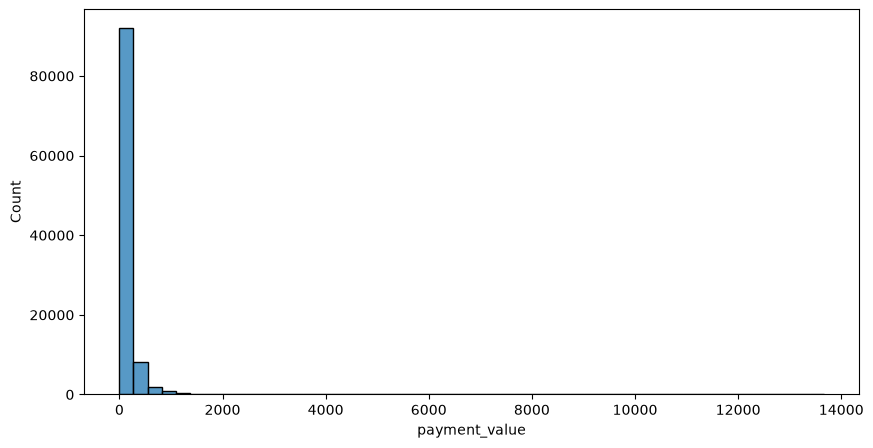

In [36]:
#distribution of payment values
plt.figure(figsize=(10,5))
sns.histplot(payments["payment_value"], bins=50)
plt.show()

# Step 6: Understand Reviews

In [37]:
# Reviews distribution
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

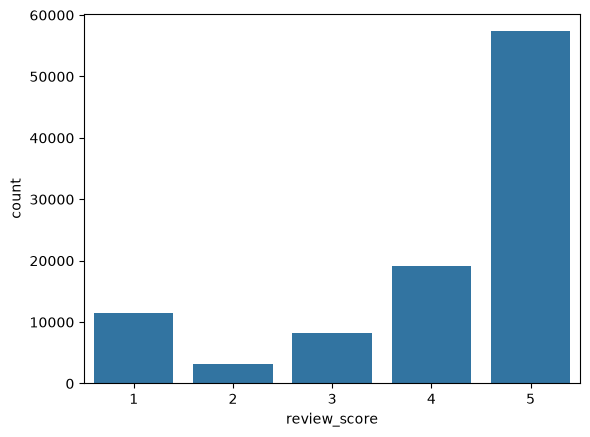

In [38]:
sns.countplot(data=reviews,
              x="review_score")
plt.show()

# Step 7: Important merge 


In [39]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [40]:
customer_orders.shape


(99441, 12)

In [41]:
customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [45]:
customer_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='str')

# Step 8: Repeat Customers

In [42]:
repeat_customers = customer_orders.groupby(
    "customer_unique_id"
)["order_id"].nunique()


In [43]:
repeat_customers.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64

In [44]:
(repeat_customers > 1).sum()

np.int64(2997)

# Next Step Creating customers features 

In [46]:
# Convert dates 
customer_orders["order_purchase_timestamp"] = pd.to_datetime(
    customer_orders["order_purchase_timestamp"]
)

In [48]:
# Creating total orders
customer_features = (
    customer_orders.groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique")
    )
)

In [49]:
customer_features.head()

,total_orders
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1


In [50]:
# Last purchase date
customer_features["last_purchase_date"] = (
    customer_orders.groupby("customer_unique_id")
    ["order_purchase_timestamp"]
    .max()
)

In [51]:
# Calculating the recency of the last purchase
snapshot_date = customer_orders[
    "order_purchase_timestamp"
].max()

In [52]:
customer_features["recency_days"] = (
    snapshot_date -
    customer_features["last_purchase_date"]
).dt.days

In [53]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [54]:
customer_orders_payments = customer_orders.merge(
    payments,
    on="order_id",
    how="left"
)

In [55]:
revenue_features = (
    customer_orders_payments
    .groupby("customer_unique_id")
    .agg(
        total_spent=("payment_value", "sum"),
        avg_order_value=("payment_value", "mean")
    )
)

In [56]:
customer_features = customer_features.merge(
    revenue_features,
    on="customer_unique_id"
)

In [57]:
customer_features.head()

,total_orders,last_purchase_date,recency_days,total_spent,avg_order_value
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,2018-05-10 10:56:27,160,141.90,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,2018-05-07 11:11:27,163,27.19,27.19
0000f46a3911fa3c0805444483337064,1,2017-03-10 21:05:03,585,86.22,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,2017-10-12 20:29:41,369,43.62,43.62
0004aac84e0df4da2b147fca70cf8255,1,2017-11-14 19:45:42,336,196.89,196.89


In [58]:
customer_features.describe()

,total_orders,last_purchase_date,recency_days,total_spent,avg_order_value
count,96096.000000,96096,96096.000000,96096.000000,96095.000000
mean,1.034809,2018-01-02 12:40:19.655865,287.735691,166.592492,158.708787
min,1.000000,2016-09-04 21:15:19,0.000000,0.000000,0.000000
25%,1.000000,2017-09-15 09:04:17.250000,163.000000,63.120000,60.850000
50%,1.000000,2018-01-21 19:39:16,268.000000,108.000000,103.750000
75%,1.000000,2018-05-06 20:14:49.750000,397.000000,183.530000,175.080000
max,17.000000,2018-10-17 17:30:18,772.000000,13664.080000,13664.080000
std,0.214384,NaN,153.414676,231.428332,219.491200


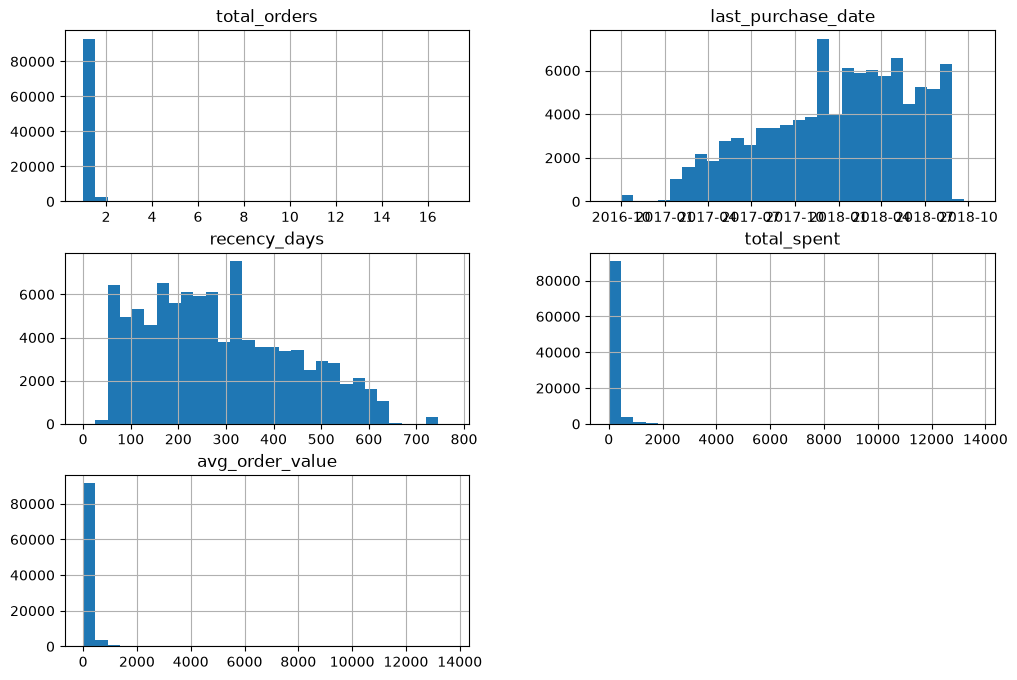

In [59]:
customer_features.hist(
    figsize=(12,8),
    bins=30
)

plt.show()

In [63]:
customer_features.isnull().sum()

total_orders          0
last_purchase_date    0
recency_days          0
total_spent           0
avg_order_value       0
dtype: int64

In [61]:
customer_features[
    customer_features["avg_order_value"].isnull()
].index

Index(['830d5b7aaa3b6f1e9ad63703bec97d23'], dtype='str', name='customer_unique_id')

In [62]:
customer_features = customer_features.dropna()

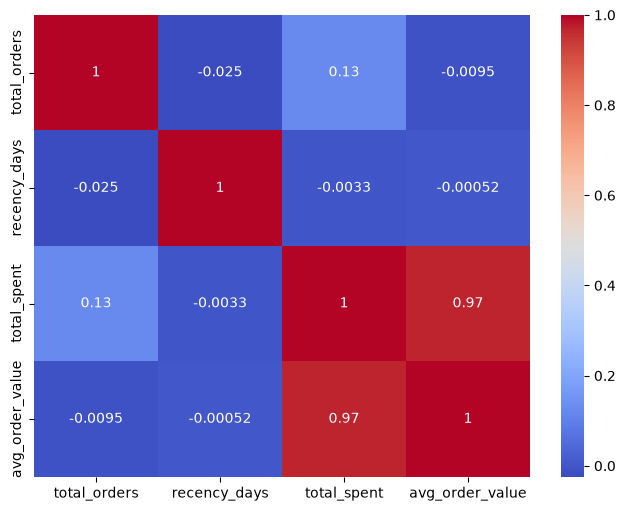

In [64]:
# coorrelation matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    customer_features.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

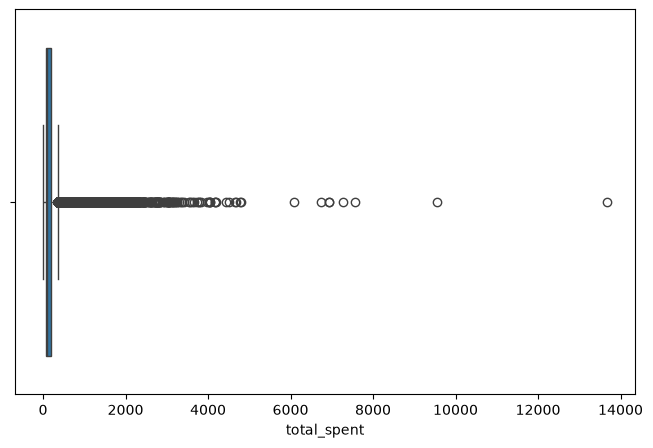

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=customer_features["total_spent"]
)

plt.show()

In [66]:
customer_features["total_spent_log"] = np.log1p(
    customer_features["total_spent"]
)

In [67]:
customer_features.describe().T

,count,mean,min,25%,50%,75%,max,std
total_orders,96095.0,1.034809,1.0,1.0,1.0,1.0,17.0,0.214385
last_purchase_date,96095,2018-01-02 12:47:25.848920,2016-09-04 21:15:19,2017-09-15 09:06:48.500000,2018-01-21 19:44:46,2018-05-06 20:14:54.500000,2018-10-17 17:30:18,NaN
recency_days,96095.0,287.730756,0.0,163.0,268.0,397.0,772.0,153.407846
total_spent,96095.0,166.594226,0.0,63.12,108.0,183.53,13664.08,231.428912
avg_order_value,96095.0,158.708787,0.0,60.85,103.75,175.08,13664.08,219.4912
total_spent_log,96095.0,4.733116,0.0,4.160756,4.691348,5.217812,9.522599,0.811922


# Scaling the features 

In [69]:
from sklearn.preprocessing import StandardScaler

features = customer_features[
    [
        "total_orders",
        "recency_days",
        "total_spent_log",
        "avg_order_value"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [70]:
# Then Find the Optimal Number of Clusters
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

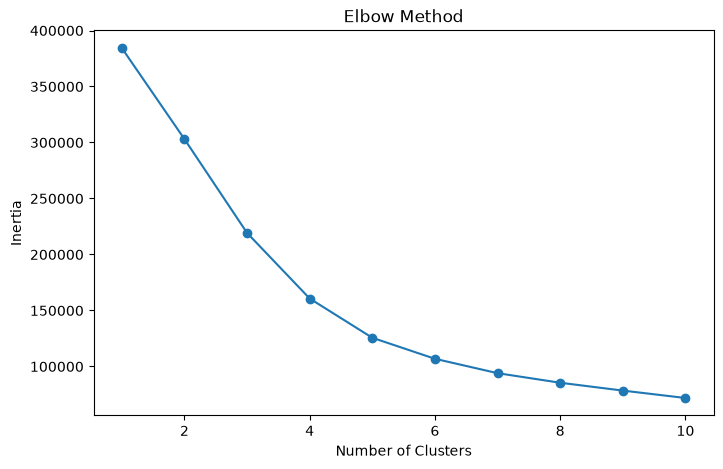

In [71]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [72]:
# Train the KMeans model with the optimal number of clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

customer_features["cluster"] = kmeans.fit_predict(
    scaled_features
)

In [73]:
customer_features["cluster"].value_counts()

cluster
0    35562
1    27700
3    26868
2     2986
4     2979
Name: count, dtype: int64

In [74]:
# Analyze the clusters 
cluster_summary = (
    customer_features
    .groupby("cluster")
    .agg({
        "total_orders":"mean",
        "recency_days":"mean",
        "total_spent":"mean",
        "avg_order_value":"mean"
    })
)

cluster_summary

,total_orders,recency_days,total_spent,avg_order_value
cluster,,,,
0,1.000000,197.385496,67.555136,66.408462
1,1.000000,221.038736,234.805135,230.904290
2,2.116209,268.009712,301.904628,139.197362
3,1.000000,476.185946,111.087123,108.689365
4,1.004028,306.428332,1079.623394,1059.934585


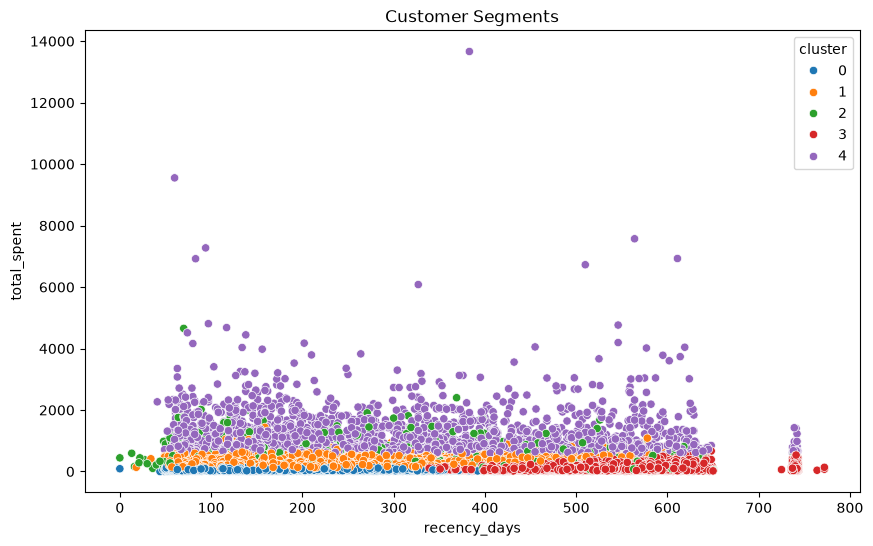

In [75]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_features,
    x="recency_days",
    y="total_spent",
    hue="cluster",
    palette="tab10"
)

plt.title("Customer Segments")
plt.show()

In [76]:
customer_features.groupby("cluster").mean()

,total_orders,last_purchase_date,recency_days,total_spent,avg_order_value,total_spent_log
cluster,,,,,,
0,1.000000,2018-04-02 21:06:25.568415,197.385496,67.555136,66.408462,4.136303
1,1.000000,2018-03-10 05:24:10.993574,221.038736,234.805135,230.904290,5.374516
2,2.116209,2018-01-22 06:05:37.125921,268.009712,301.904628,139.197362,5.461784
3,1.000000,2017-06-28 01:47:57.589735,476.185946,111.087123,108.689365,4.542870
4,1.004028,2017-12-14 20:15:05.138301,306.428332,1079.623394,1059.934585,6.879070


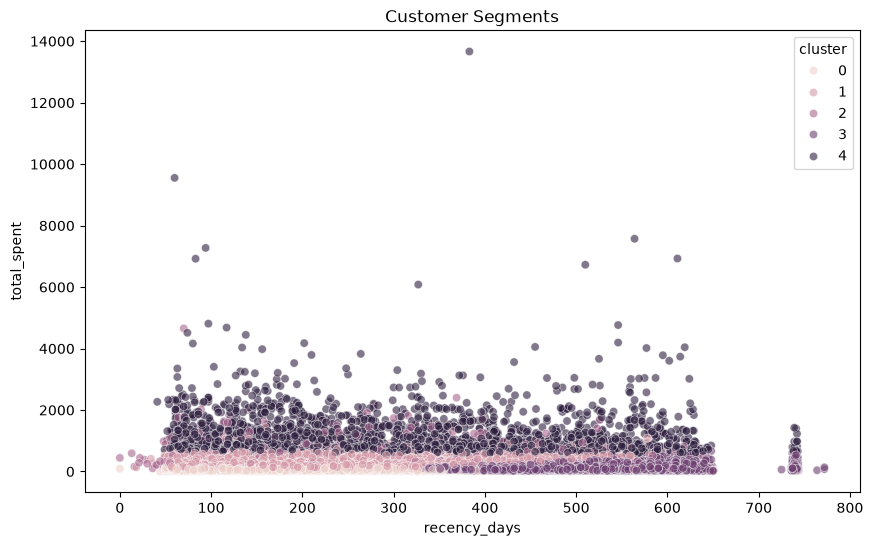

In [77]:
# visualize the clusters using a pairplot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_features,
    x="recency_days",
    y="total_spent",
    hue="cluster",
    alpha=0.6
)

plt.title("Customer Segments")
plt.show()

In [78]:
# Creating labels
cluster_names = {
    0: "Budget Buyers",
    1: "Standard Customers",
    2: "Loyal Customers",
    3: "Dormant Customers",
    4: "VIP Customers"
}

customer_features["segment"] = (
    customer_features["cluster"]
    .map(cluster_names)
)

## Customer Segmentation Results

    Cluster 0: Budget Buyers
    Cluster 1: Standard Customers
    Cluster 2: Loyal Customers
    Cluster 3: Dormant Customers
    Cluster 4: VIP Customers

In [79]:
customer_features.to_csv(
    "../data/customer_features.csv",
    index=True
)

# Retention Prediction

---

In [80]:
# Create a Customer Purchase History Table
customer_orders = customer_orders.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
)

customer_orders[
    ["customer_unique_id",
     "order_id",
     "order_purchase_timestamp"]
].head()

,customer_unique_id,order_id,order_purchase_timestamp
52798,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27
73889,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27
26460,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03
98493,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41
41564,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42


In [81]:
# Count Purchases Per Customer
purchase_counts = (
    customer_orders
    .groupby("customer_unique_id")
    ["order_id"]
    .nunique()
)

purchase_counts.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64

In [82]:
# Creating retention rate
customer_features["retained"] = (
    customer_features["total_orders"] > 1
).astype(int)

In [83]:
customer_features["retained"].value_counts()

retained
0    93098
1     2997
Name: count, dtype: int64

In [84]:
customer_features["retained"].value_counts(normalize=True)

retained
0    0.968812
1    0.031188
Name: proportion, dtype: float64

In [85]:
# Preparing features 
X = customer_features[
    [
        "recency_days",
        "total_spent_log",
        "avg_order_value"
    ]
]

y = customer_features["retained"]

In [86]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
# First model 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [88]:
y_pred = rf.predict(X_test)

In [89]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18620
           1       0.75      0.71      0.73       599

    accuracy                           0.98     19219
   macro avg       0.87      0.85      0.86     19219
weighted avg       0.98      0.98      0.98     19219



In [90]:
customer_features["retained"] = (
    customer_features["total_orders"] > 1
).astype(int)

customer_features["retained"].value_counts()

retained
0    93098
1     2997
Name: count, dtype: int64

In [91]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
2,avg_order_value,0.527059
1,total_spent_log,0.347571
0,recency_days,0.125370
